<a href="https://colab.research.google.com/github/MUKESHKUMAR-21/DeepLearning/blob/main/DL_Exp03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 170M/170M [01:17<00:00, 2.19MB/s]


Epoch 1: Loss = 1.7020, Accuracy = 40.09%
Epoch 2: Loss = 1.4863, Accuracy = 47.91%
Epoch 3: Loss = 1.3863, Accuracy = 51.49%
Epoch 4: Loss = 1.3161, Accuracy = 54.25%
Epoch 5: Loss = 1.2586, Accuracy = 56.03%
Epoch 6: Loss = 1.2107, Accuracy = 58.02%
Epoch 7: Loss = 1.1638, Accuracy = 59.64%
Epoch 8: Loss = 1.1149, Accuracy = 61.42%
Epoch 9: Loss = 1.0747, Accuracy = 62.90%
Epoch 10: Loss = 1.0394, Accuracy = 64.13%
Epoch 1: Loss = 1.6423, Accuracy = 42.44%
Epoch 2: Loss = 1.4381, Accuracy = 49.80%
Epoch 3: Loss = 1.3462, Accuracy = 53.13%
Epoch 4: Loss = 1.2741, Accuracy = 55.64%
Epoch 5: Loss = 1.2193, Accuracy = 57.84%
Epoch 6: Loss = 1.1604, Accuracy = 59.72%
Epoch 7: Loss = 1.1121, Accuracy = 61.51%
Epoch 8: Loss = 1.0631, Accuracy = 63.31%
Epoch 9: Loss = 1.0246, Accuracy = 64.51%
Epoch 10: Loss = 0.9808, Accuracy = 66.11%


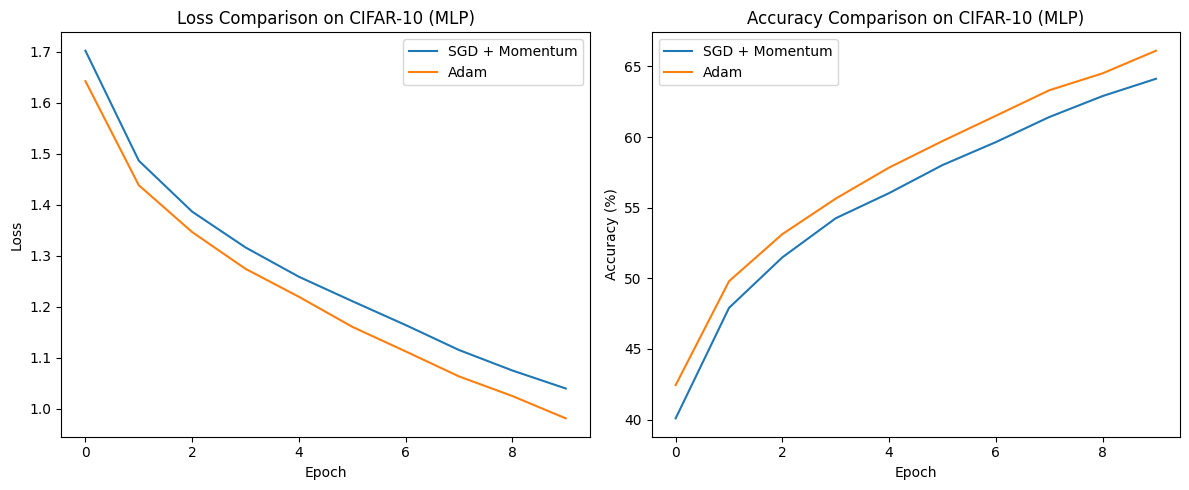

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        model.train()
        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100.0 * correct / total
        losses.append(avg_loss)
        accuracies.append(accuracy)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")
    return losses, accuracies

model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)

model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.tight_layout()
plt.show()